<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <img src="../assets/branding/logoUgrupo.png" alt="Universidad del Magdalena y GIDSYC" style="height: 76px; max-width: 34%; object-fit: contain;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Modelos de difusión para IA generativa</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 10</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Flow matching y transporte de probabilidad</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Semillero GIDSYC | Facultad de Ingenierías | Programa de Ingeniería de Sistemas</div>
    </div>
    <img src="../assets/branding/logo_semillero.png" alt="Semillero GIDSYC" style="height: 74px; object-fit: contain;">
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
  <div><strong>Grupo:</strong> GIDSYC</div>
  <div><strong>Unidad:</strong> Semillero GIDSYC</div>
  <div><strong>Universidad:</strong> Universidad del Magdalena</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>

## Pregunta directriz

> ¿Podemos generar datos aprendiendo directamente un campo que transporte ruido hacia datos?

En los notebooks anteriores construimos la generación como un proceso inverso de denoising. La muestra se inicia en ruido y se transforma mediante una cadena de pasos que intenta retirar ruido gradualmente. Flow matching presenta una mirada diferente: en lugar de aprender explícitamente la reversa de una cadena estocástica, aprende un campo de velocidad que mueve una distribución simple hacia la distribución de datos.

Esta formulación no elimina la idea de distribución. La desplaza hacia una pregunta geométrica: qué campo vectorial debe seguir una partícula para que, al mover muchas partículas, la nube inicial termine pareciéndose a los datos.

## Objetivos

Al finalizar este notebook, el estudiante debería estar en capacidad de:

1. Formular la generación como transporte entre una distribución base y una distribución de datos.
2. Interpretar un campo de velocidad dependiente del tiempo $v(x,t)$.
3. Explicar la ecuación de continuidad como restricción de conservación de masa probabilística.
4. Construir un camino de probabilidad por interpolación lineal.
5. Entrenar una red pequeña para aproximar un campo de flow matching.
6. Generar muestras integrando una ODE aprendida.
7. Comparar conceptualmente flow matching con DDPM y score matching.

## Marco conceptual

En DDPM, la generación se entiende como una cadena inversa que parte de una distribución gaussiana y reduce ruido paso a paso. En score matching, la red puede interpretarse como una aproximación del gradiente del logaritmo de una densidad perturbada. Flow matching reorganiza estas ideas: el objeto aprendido es un campo de velocidad.

Un campo de velocidad asigna a cada punto $x$ y a cada tiempo $t$ un vector $v(x,t)$. Si una partícula está en la posición $x(t)$, su evolución está dada por una ecuación diferencial ordinaria:

$$
\frac{d x(t)}{dt}=v(x(t),t).
$$

Si muchas partículas siguen ese campo, inducen una familia de distribuciones $p_t$. La generación consiste en iniciar partículas desde una distribución simple $p_0$ y transportarlas hasta una distribución final $p_1$ que represente los datos.

## Formulación matemática

Sea $p_0$ una distribución base simple, por ejemplo una normal estándar, y sea $p_1$ la distribución de datos. Flow matching introduce una familia de distribuciones intermedias $p_t$, con $t\in[0,1]$, que conecta ambos extremos:

$$
p_0 \longrightarrow p_t \longrightarrow p_1.
$$

Un campo de velocidad $v_t(x)$ transporta esta familia si las densidades satisfacen la ecuación de continuidad:

$$
\partial_t p_t(x)+\nabla_x\cdot\left(p_t(x)v_t(x)\right)=0.
$$

Esta ecuación expresa conservación de masa probabilística: la densidad no aparece ni desaparece arbitrariamente; cambia porque el campo desplaza probabilidad a través del espacio.

En la versión pedagógica que usaremos, tomamos pares independientes

$$
z\sim p_0,
\qquad
x_1\sim p_{\mathrm{data}},
$$

y definimos el camino condicional lineal

$$
x_t=(1-t)z+t x_1.
$$

La velocidad condicional de ese punto es constante:

$$
u_t(x_t\mid z,x_1)=\frac{d x_t}{dt}=x_1-z.
$$

El modelo aprende un campo $v_\theta(x_t,t)$ resolviendo el problema de regresión:

$$
\mathcal{L}(\theta)
=
\mathbb{E}_{z,x_1,t}
\left[
\left\|
v_\theta(x_t,t)-(x_1-z)
\right\|_2^2
\right],
\qquad
t\sim\mathcal{U}(0,1).
$$

Después de entrenar, generamos resolviendo la ODE aprendida:

$$
\frac{d x(t)}{dt}=v_\theta(x(t),t),
\qquad
x(0)\sim p_0.
$$

<div style="margin: 18px 0 10px 0; text-align: center;">
  <img src="../assets/figures/formulacion_flow_matching.png" alt="Formulación de flow matching" style="max-width: 100%; border: 1px solid #d0d7de; border-radius: 6px;" />
</div>

<div style="text-align: center; color: #4a5568; font-size: 0.95em; margin-bottom: 6px;">
  Flow matching aprende un campo de velocidad que transporta una distribución base hacia la distribución de datos.
</div>

## Preparación del entorno

El experimento será bidimensional para que el campo de velocidad sea visible. Entrenaremos una red pequeña en PyTorch. El objetivo no es competir con modelos modernos de imágenes, sino aislar el mecanismo matemático de flow matching.

In [1]:
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

CWD = Path.cwd()
if CWD.name == "notebooks":
    ROOT = CWD.parent
elif (CWD / "src" / "difusion").exists():
    ROOT = CWD
else:
    ROOT = CWD / "courses" / "modelos_difusion_ia_generativa"

SEED = 20260425
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("PyTorch:", torch.__version__)
print("Dispositivo:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(DEVICE))

PyTorch: 2.8.0+cu126
Dispositivo: cuda:0
GPU: NVIDIA RTX A6000


## Distribuciones inicial y final

Usaremos como distribución base una normal estándar en $\mathbb{R}^2$:

$$
p_0=\mathcal{N}(0,I).
$$

La distribución de datos será una mezcla de tres gaussianas. Esta elección mantiene continuidad con el notebook 09 y permite observar si el campo aprendido separa la masa inicial hacia varios modos.

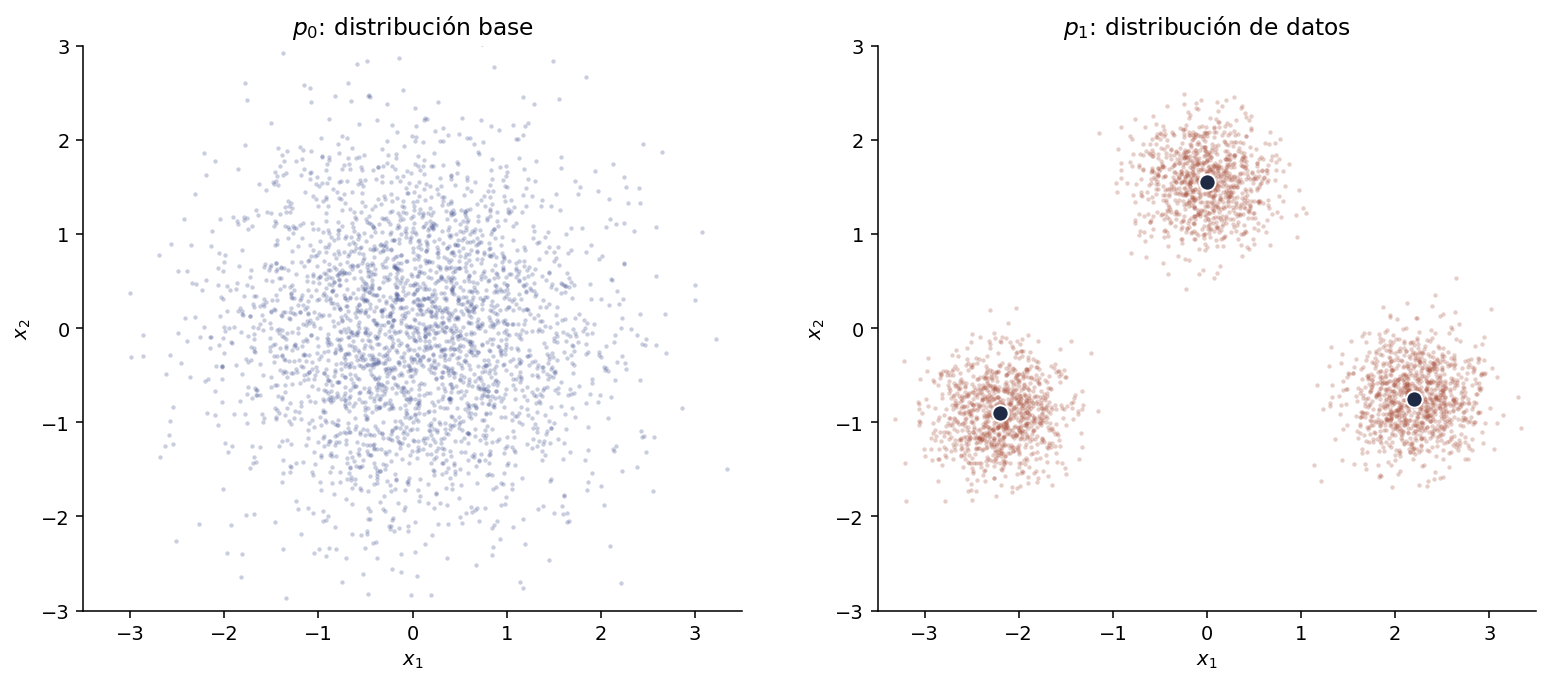

In [2]:
means_np = np.array([[-2.2, -0.9], [0.0, 1.55], [2.2, -0.75]], dtype=np.float32)
weights_np = np.array([0.34, 0.32, 0.34], dtype=np.float32)
target_sigma = 0.35
dim = 2


def sample_base_np(n, rng=None):
    local_rng = np.random.default_rng(SEED) if rng is None else rng
    return local_rng.normal(size=(n, dim)).astype(np.float32)


def sample_target_np(n, rng=None):
    local_rng = np.random.default_rng(SEED) if rng is None else rng
    comp = local_rng.choice(len(means_np), size=n, p=weights_np)
    x = means_np[comp] + target_sigma * local_rng.normal(size=(n, dim)).astype(np.float32)
    return x.astype(np.float32), comp


base_samples = sample_base_np(3_000, rng=np.random.default_rng(SEED + 1))
target_samples, target_components = sample_target_np(3_000, rng=np.random.default_rng(SEED + 2))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
axes[0].scatter(base_samples[:, 0], base_samples[:, 1], s=5, alpha=0.28, color="#3f4f8f", linewidths=0)
axes[0].set_title("$p_0$: distribución base")
axes[1].scatter(target_samples[:, 0], target_samples[:, 1], s=5, alpha=0.28, color="#a84f3b", linewidths=0)
axes[1].scatter(means_np[:, 0], means_np[:, 1], s=70, color="#1f2a44", edgecolor="white", linewidth=1.0)
axes[1].set_title("$p_1$: distribución de datos")
for ax in axes:
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.0, 3.0)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_aspect("equal")
fig.tight_layout()

## Camino lineal entre pares

Para cada par $(z,x_1)$, el punto intermedio se define como

$$
x_t=(1-t)z+t x_1.
$$

Esta construcción no dice que cada punto real deba estar emparejado con un único ruido de manera semántica. Es un mecanismo de entrenamiento: produce ejemplos supervisados de posiciones intermedias y velocidades. El campo aprendido no memoriza trayectorias individuales; ajusta una velocidad promedio condicionada por la posición y el tiempo.

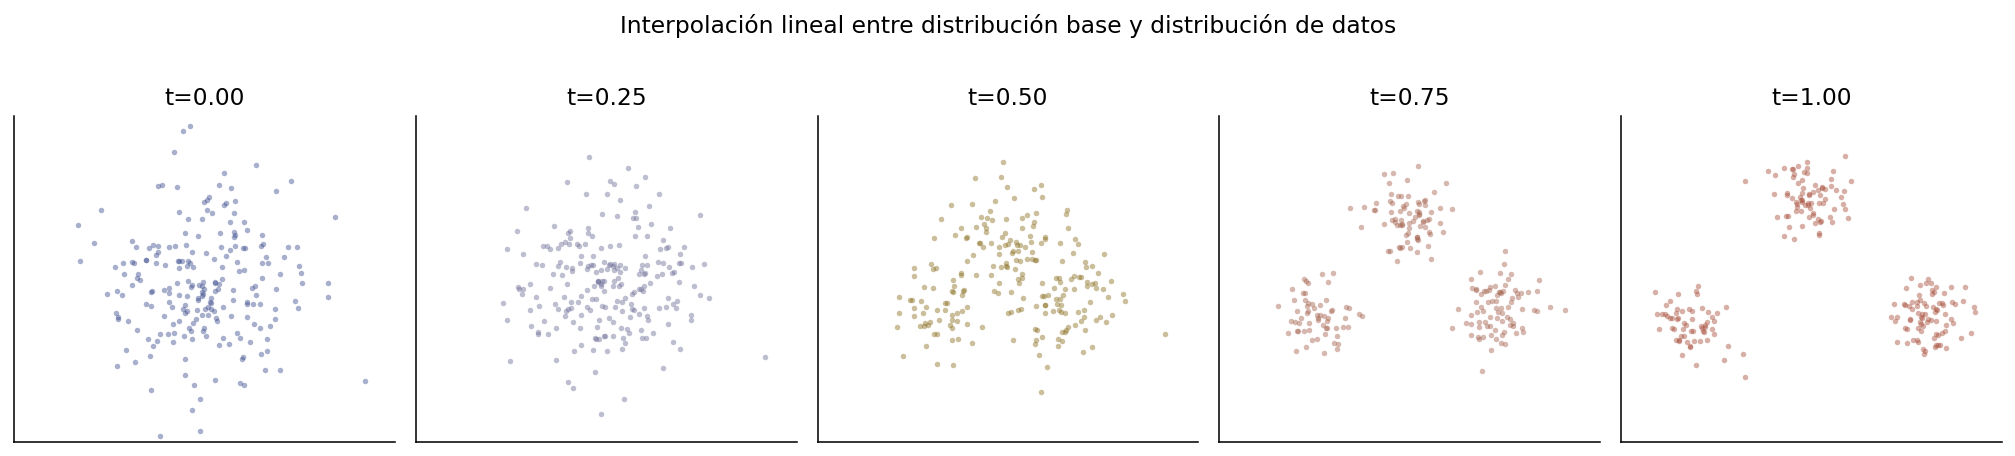

In [3]:
path_rng = np.random.default_rng(SEED + 3)
z_demo = sample_base_np(220, rng=path_rng)
x1_demo, _ = sample_target_np(220, rng=path_rng)
times_to_show = [0.0, 0.25, 0.50, 0.75, 1.0]
colors = ["#3f4f8f", "#6f6f99", "#8a6f22", "#a4634e", "#a84f3b"]

fig, axes = plt.subplots(1, len(times_to_show), figsize=(14.5, 3.2), sharex=True, sharey=True)
for ax, t, color in zip(axes, times_to_show, colors):
    xt = (1 - t) * z_demo + t * x1_demo
    ax.scatter(xt[:, 0], xt[:, 1], s=8, alpha=0.45, color=color, linewidths=0)
    ax.set_title(f"t={t:.2f}")
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.0, 3.0)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Interpolación lineal entre distribución base y distribución de datos", y=1.04)
fig.tight_layout()

## Velocidades supervisadas

En este camino lineal, la velocidad condicional es

$$
u_t=x_1-z.
$$

En una misma región del plano pueden pasar trayectorias distintas con velocidades distintas. Por eso el modelo no recupera una flecha individual para cada par. Bajo pérdida cuadrática, aprende el promedio condicional:

$$
v^\star(x,t)
=
\mathbb{E}
\left[
x_1-z
\mid
x_t=x
\right].
$$

Esta ecuación es importante: el campo aprendido es una propiedad agregada de la distribución de caminos, no una tabla de correspondencias punto a punto.

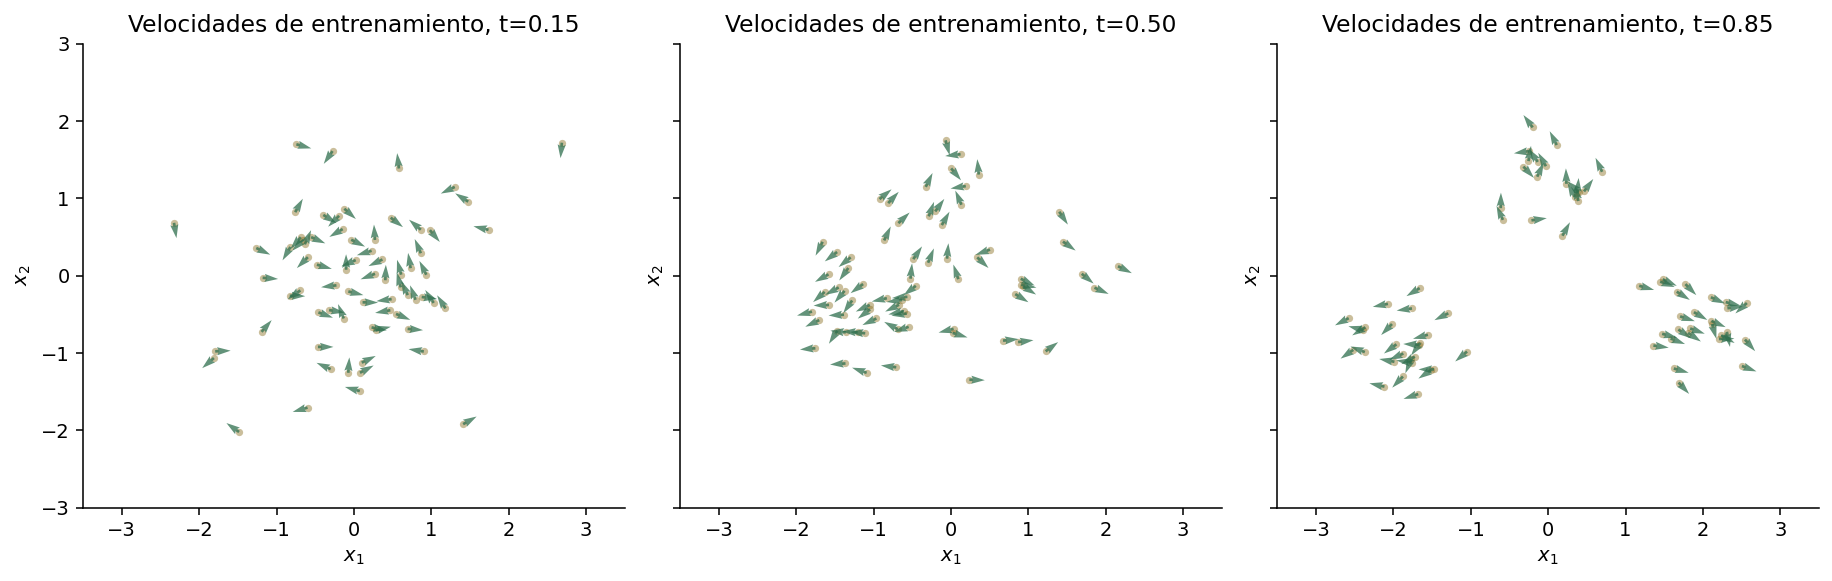

In [4]:
t_values = [0.15, 0.50, 0.85]
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2), sharex=True, sharey=True)
for ax, t in zip(axes, t_values):
    z = sample_base_np(70, rng=np.random.default_rng(SEED + int(t * 1000)))
    x1, _ = sample_target_np(70, rng=np.random.default_rng(SEED + int(t * 1000) + 50))
    xt = (1 - t) * z + t * x1
    u = x1 - z
    norm = np.linalg.norm(u, axis=1, keepdims=True)
    direction = u / np.maximum(norm, 1e-8)
    ax.scatter(xt[:, 0], xt[:, 1], s=14, color="#8a6f22", alpha=0.45, linewidths=0)
    ax.quiver(
        xt[:, 0],
        xt[:, 1],
        direction[:, 0],
        direction[:, 1],
        angles="xy",
        scale_units="xy",
        scale=5.0,
        width=0.005,
        color="#2f6f4e",
        alpha=0.75,
    )
    ax.set_title(f"Velocidades de entrenamiento, t={t:.2f}")
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.0, 3.0)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_aspect("equal")
fig.tight_layout()

## Entrenamiento de un campo de velocidad

La red recibe el punto intermedio $x_t$ y el tiempo $t$. Su salida es un vector en $\mathbb{R}^2$:

$$
v_\theta(x_t,t)\in\mathbb{R}^2.
$$

La pérdida compara esa salida contra la velocidad condicional $x_1-z$. Este entrenamiento es barato porque todo ocurre en dos dimensiones.

In [5]:
means = torch.tensor(means_np, dtype=torch.float32, device=DEVICE)
weights = torch.tensor(weights_np, dtype=torch.float32, device=DEVICE)


def sample_base_torch(n):
    return torch.randn(n, dim, device=DEVICE)


def sample_target_torch(n):
    comp = torch.multinomial(weights, n, replacement=True)
    x = means[comp] + target_sigma * torch.randn(n, dim, device=DEVICE)
    return x, comp


class VelocityMLP(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, x, t):
        features = torch.cat([x, t.view(-1, 1)], dim=1)
        return self.net(features)


model = VelocityMLP(hidden=128).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3)

TRAIN_STEPS = 3_000
BATCH_SIZE = 1_024
loss_history = []

start = time.perf_counter()
model.train()
for step in range(1, TRAIN_STEPS + 1):
    z = sample_base_torch(BATCH_SIZE)
    x1, _ = sample_target_torch(BATCH_SIZE)
    t = torch.rand(BATCH_SIZE, device=DEVICE)
    xt = (1.0 - t[:, None]) * z + t[:, None] * x1
    target_velocity = x1 - z

    velocity_pred = model(xt, t)
    loss = torch.mean((velocity_pred - target_velocity) ** 2)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    loss_history.append(float(loss.detach().cpu()))
    if step % 500 == 0:
        print(f"paso {step:04d}/{TRAIN_STEPS} | loss={loss_history[-1]:.4f}")

if DEVICE.type == "cuda":
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start
print(f"Tiempo total de entrenamiento: {elapsed:.2f} s")

paso 0500/3000 | loss=1.9863
paso 1000/3000 | loss=1.9240
paso 1500/3000 | loss=1.9831
paso 2000/3000 | loss=1.9821
paso 2500/3000 | loss=1.8729
paso 3000/3000 | loss=1.9412
Tiempo total de entrenamiento: 14.00 s


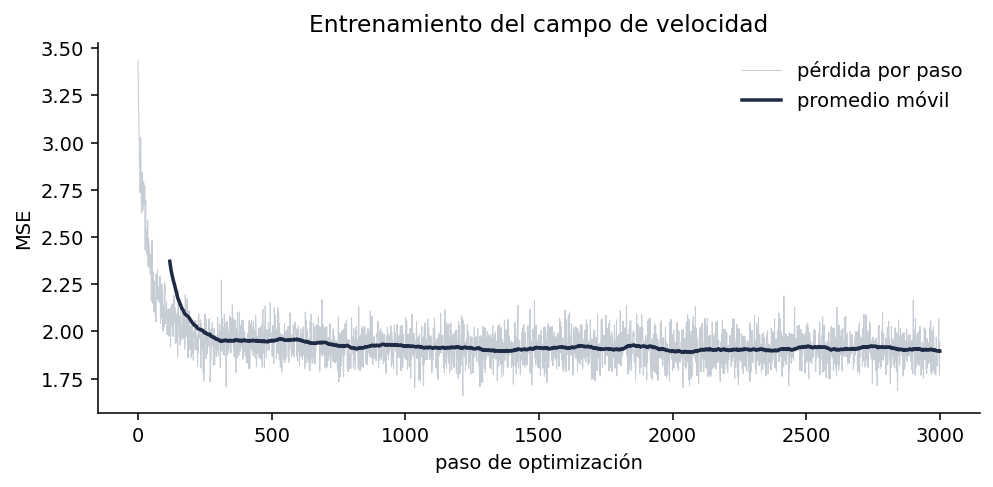

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(loss_history, color="#9aa4b2", linewidth=0.55, alpha=0.55, label="pérdida por paso")
window = 120
if len(loss_history) >= window:
    kernel = np.ones(window) / window
    moving = np.convolve(np.asarray(loss_history), kernel, mode="valid")
    ax.plot(np.arange(window - 1, len(loss_history)), moving, color="#1f2a44", linewidth=1.8, label="promedio móvil")
ax.set_title("Entrenamiento del campo de velocidad")
ax.set_xlabel("paso de optimización")
ax.set_ylabel("MSE")
ax.legend(frameon=False)
fig.tight_layout()

La pérdida no debe interpretarse como error de clasificación ni como distancia directa entre muestras generadas y muestras reales. Es un error de regresión sobre velocidades. El criterio visual relevante aparecerá al integrar el campo: si las partículas iniciales se organizan en la geometría de la distribución objetivo, el campo aprendió una dinámica útil.

## Campo aprendido

Visualicemos el campo $v_\theta(x,t)$ en distintos tiempos. Al comienzo, el campo debe actuar sobre una nube cercana a la normal estándar; hacia el final, debe ajustar partículas cerca de los modos de la distribución de datos.

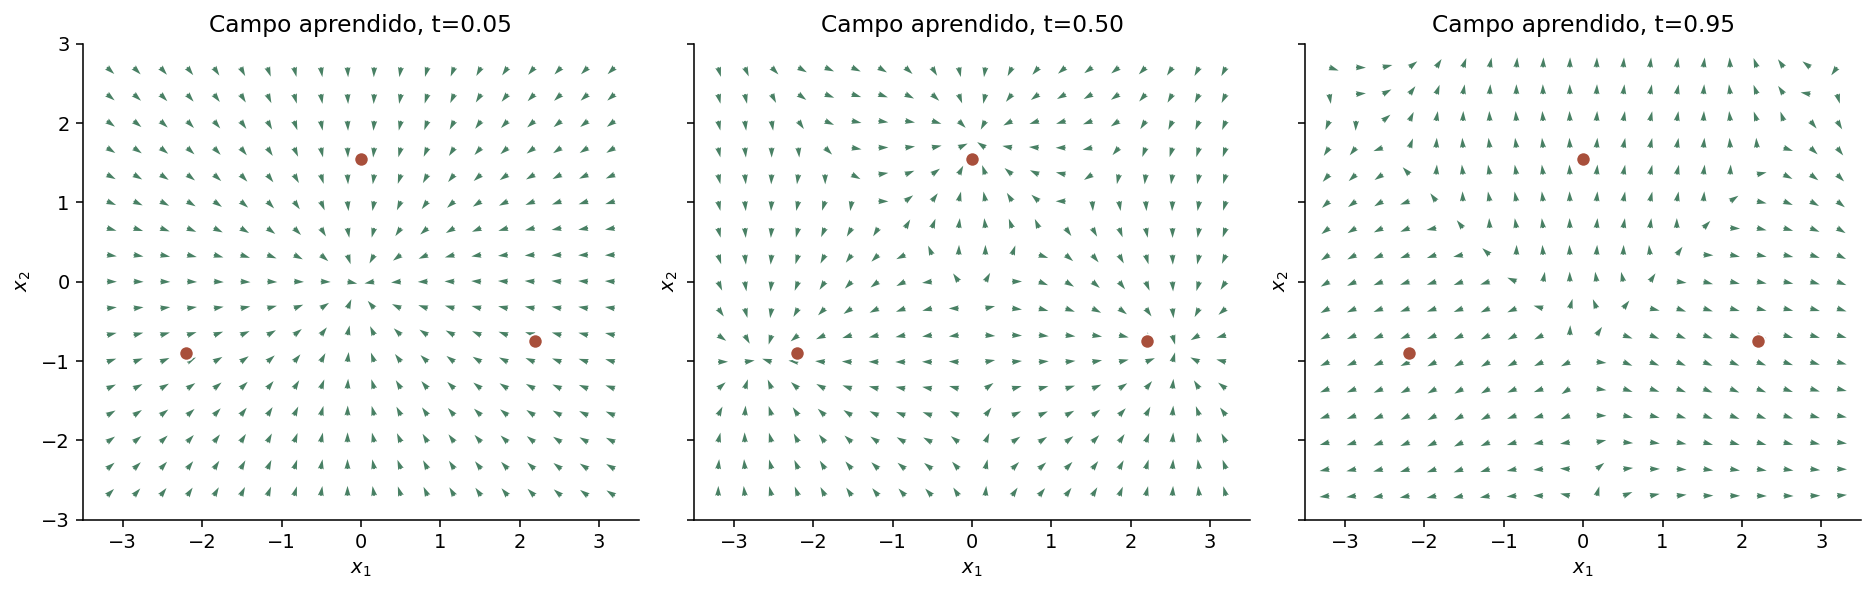

In [7]:
@torch.no_grad()
def learned_velocity_np(points_np, t_value):
    points = torch.tensor(points_np, dtype=torch.float32, device=DEVICE)
    t = torch.full((points.shape[0],), float(t_value), dtype=torch.float32, device=DEVICE)
    velocity = model(points, t)
    return velocity.detach().cpu().numpy()


qx = np.linspace(-3.2, 3.2, 20)
qy = np.linspace(-2.7, 2.7, 17)
qxx, qyy = np.meshgrid(qx, qy)
grid = np.column_stack([qxx.ravel(), qyy.ravel()]).astype(np.float32)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.3), sharex=True, sharey=True)
for ax, t in zip(axes, [0.05, 0.50, 0.95]):
    velocity = learned_velocity_np(grid, t)
    norm = np.linalg.norm(velocity, axis=1, keepdims=True)
    direction = velocity / np.maximum(norm, 1e-8)
    ax.quiver(
        grid[:, 0],
        grid[:, 1],
        direction[:, 0],
        direction[:, 1],
        angles="xy",
        scale_units="xy",
        scale=8.0,
        width=0.0042,
        color="#2f6f4e",
        alpha=0.88,
    )
    ax.scatter(means_np[:, 0], means_np[:, 1], s=55, color="#a84f3b", edgecolor="white", linewidth=1.0)
    ax.set_title(f"Campo aprendido, t={t:.2f}")
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.0, 3.0)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_aspect("equal")
fig.tight_layout()

## Generación por integración de la ODE

Una vez entrenado el campo, la generación se realiza iniciando puntos $x(0)\sim p_0$ e integrando:

$$
x_{n+1}
=
x_n
+
\Delta t\,
v_\theta(x_n,t_n).
$$

Este esquema de Euler es deliberadamente simple. En sistemas reales se pueden usar integradores más sofisticados, pero aquí conviene ver la idea sin esconderla detrás de una rutina numérica compleja.

In [8]:
@torch.no_grad()
def euler_sample(n=2_000, steps=80, keep_trajectory=False):
    model.eval()
    x = torch.randn(n, dim, device=DEVICE)
    dt = 1.0 / steps
    snapshots = []
    if keep_trajectory:
        snapshots.append(x.detach().cpu().numpy())
    for i in range(steps):
        t_value = i / steps
        t = torch.full((n,), float(t_value), device=DEVICE)
        x = x + dt * model(x, t)
        if keep_trajectory and i in {19, 39, 59, 79}:
            snapshots.append(x.detach().cpu().numpy())
    if keep_trajectory:
        return x.detach().cpu().numpy(), snapshots
    return x.detach().cpu().numpy()


generated_samples, snapshots = euler_sample(n=2_500, steps=90, keep_trajectory=True)

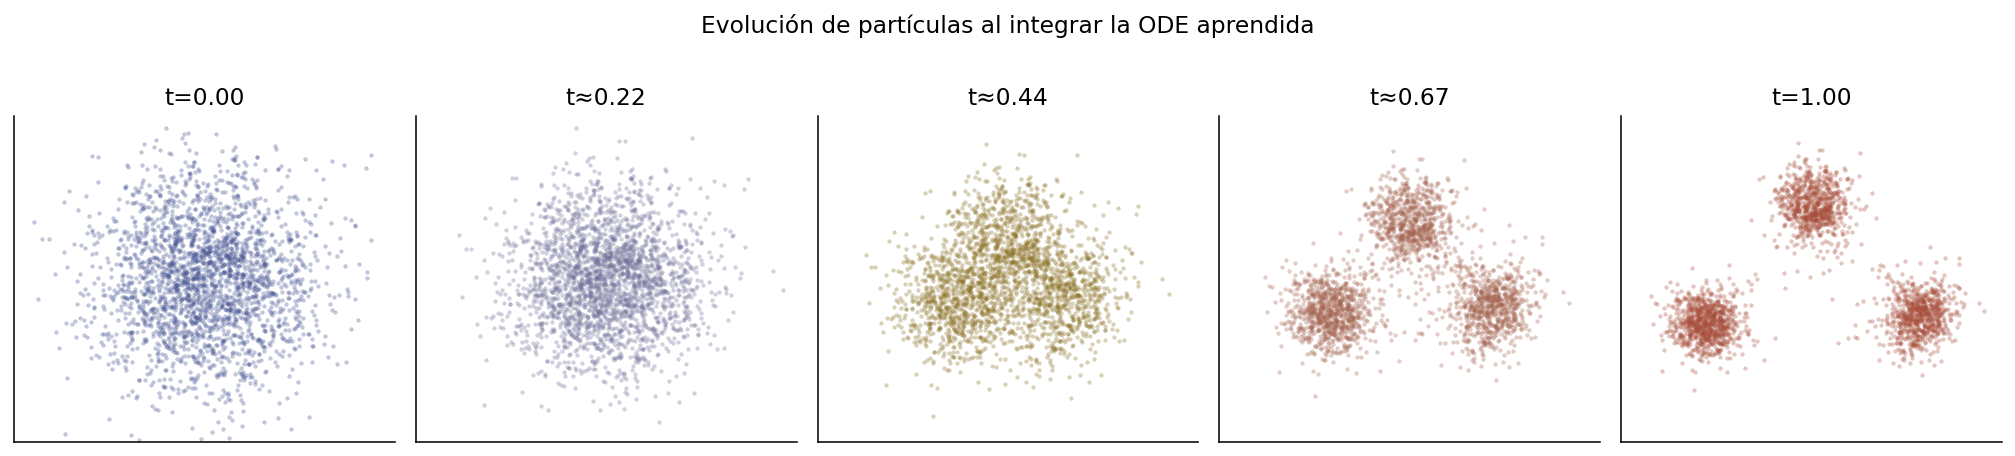

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(14.5, 3.2), sharex=True, sharey=True)
titles = ["t=0.00", "t≈0.22", "t≈0.44", "t≈0.67", "t=1.00"]
colors = ["#3f4f8f", "#6f6f99", "#8a6f22", "#a4634e", "#a84f3b"]
for ax, pts, title, color in zip(axes, snapshots, titles, colors):
    ax.scatter(pts[:, 0], pts[:, 1], s=5, alpha=0.32, color=color, linewidths=0)
    ax.set_title(title)
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.0, 3.0)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Evolución de partículas al integrar la ODE aprendida", y=1.04)
fig.tight_layout()

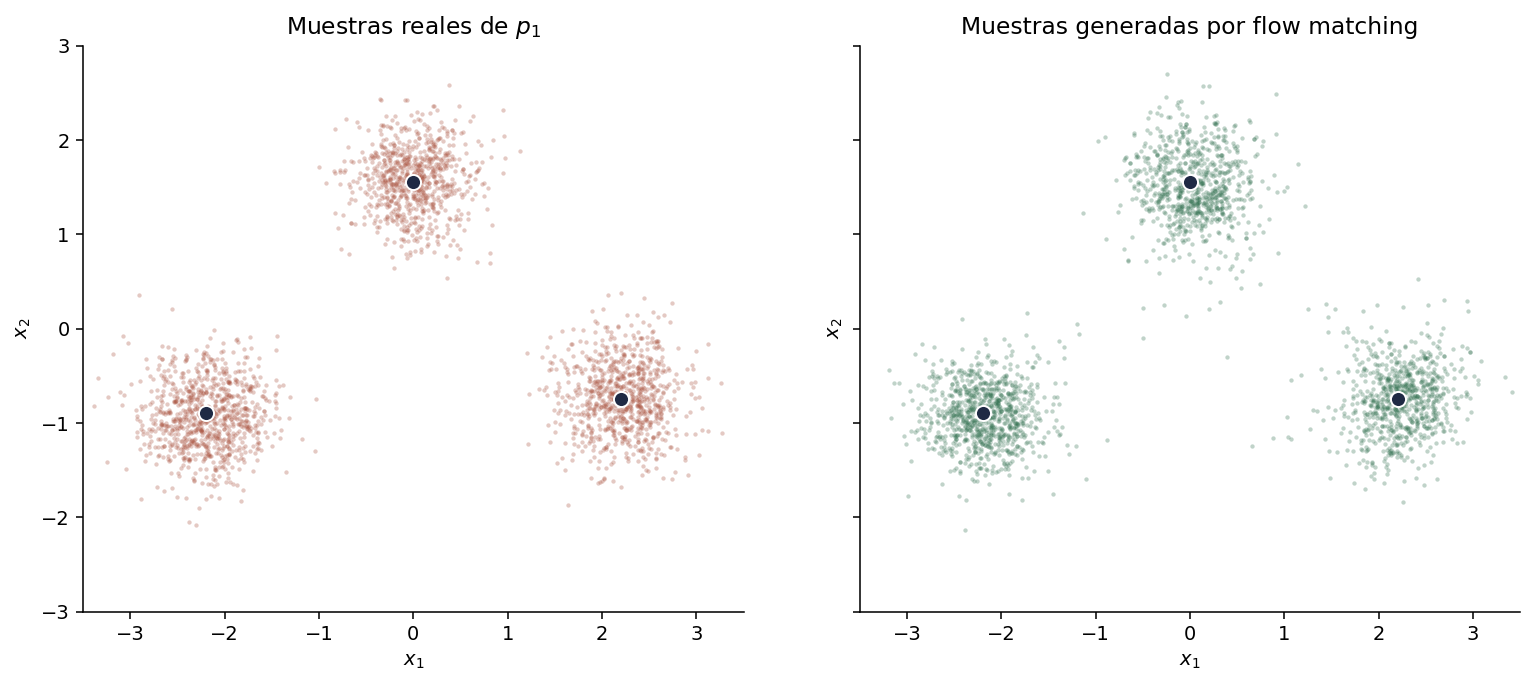

In [10]:
real_samples, _ = sample_target_np(2_500, rng=np.random.default_rng(SEED + 20))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), sharex=True, sharey=True)
axes[0].scatter(real_samples[:, 0], real_samples[:, 1], s=5, alpha=0.30, color="#a84f3b", linewidths=0)
axes[0].set_title("Muestras reales de $p_1$")
axes[1].scatter(generated_samples[:, 0], generated_samples[:, 1], s=5, alpha=0.30, color="#2f6f4e", linewidths=0)
axes[1].set_title("Muestras generadas por flow matching")
for ax in axes:
    ax.scatter(means_np[:, 0], means_np[:, 1], s=60, color="#1f2a44", edgecolor="white", linewidth=1.0)
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.0, 3.0)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_aspect("equal")
fig.tight_layout()

## Comparación conceptual con DDPM

DDPM y flow matching comparten la idea de transformar una distribución simple en una distribución de datos, pero organizan el problema de forma distinta.

En DDPM, se define un proceso directo de ruido y se aprende una cadena inversa de denoising. El muestreo suele escribirse como una secuencia de transiciones discretas. En flow matching, se define un camino de probabilidad y se aprende el campo de velocidad que transporta ese camino. El muestreo se escribe como la integración de una ODE.

Esta diferencia no es solo de implementación. Cambia el objeto matemático central: en DDPM el estudiante piensa en ruido, score y pasos inversos; en flow matching piensa en velocidades, continuidad y transporte.

## Limitaciones del experimento

El camino lineal usado aquí es una elección simple, no la única posible. El acoplamiento independiente entre $z$ y $x_1$ tampoco es necesariamente óptimo desde el punto de vista de transporte. Para un curso introductorio, esta elección tiene una ventaja: produce una supervisión directa y barata para el campo de velocidad.

En modelos de escala real aparecen decisiones adicionales: parametrización del tiempo, diseño del camino, integradores numéricos, arquitecturas de red, condicionamiento y control del costo de muestreo. Este notebook no intenta cubrir todos esos elementos; fija la formulación mínima que permite entender por qué flow matching es una alternativa natural dentro de los modelos generativos continuos.

## Síntesis

**Resultado conceptual.** Flow matching formula la generación como transporte de probabilidad. Se parte de una distribución base $p_0$, se define un camino $p_t$ hacia la distribución de datos $p_1$ y se entrena un campo de velocidad $v_\theta(x,t)$ para mover muestras a lo largo de ese camino. Una vez entrenado, el modelo genera resolviendo una ODE desde ruido inicial hasta datos sintéticos.

**Conexión con el curso.** Este notebook completa el puente entre la visión discreta de DDPM y una visión continua basada en campos. El punto importante no es memorizar otra técnica aislada, sino reconocer que los modelos generativos modernos pueden estudiarse como transformaciones entre distribuciones: por cadenas estocásticas, por scores o por campos de velocidad.

## Preguntas de discusión

1. ¿Qué expresa la ecuación de continuidad en términos de conservación de masa probabilística?
2. ¿Por qué el campo aprendido en flow matching debe depender del tiempo?
3. ¿Qué diferencia hay entre una velocidad condicional $x_1-z$ y el campo promedio que aprende la red?
4. ¿En qué sentido DDPM y flow matching son dos formas de transformar una distribución simple en una distribución de datos?
5. ¿Qué limitaciones tiene el camino lineal usado en este notebook como construcción de entrenamiento?

## Continuidad

El siguiente notebook cierra el curso ubicando estas formulaciones dentro de arquitecturas generativas modernas. La pregunta ya no será solo qué proceso matemático transforma ruido en datos, sino en qué espacio conviene aplicar esa transformación: píxeles, representaciones latentes o secuencias de tokens.